## Final Lab
Kyle Vogel, Alex Elias, Matt Benson
\
DS 3022

---
### Primary Question: Can in-game shooting efficiency, rebounding, and playmaking, predict the outcome of an NBA game?



With the NBA championship in our presence, we were curious to explore which in-game factors are most important when it comes to predicting the outcome of a game (aka, who wins).To ensure accuracy and reproducibility, were using a dataset that covers all NBA games from 2004 to December of 2020. This dataset contains 26,651 Nba games worth of in-game statistics. Each row within the dataset is a specific game, with respect to its corresponding performance metrics such as: field goal percentage, free throw percentage, three-point percentage, assists, rebounds, and total points scored.(Just a few) 

Our target variable for this project will be Home Team Wins. A binary column will represent either a 1, if the home team won, or a 0, indicating the away team won. Of all games in the dataset, the home team won approximately 59% of the time, which hints that our classes are slightly imbalanced.

For our model, we’ll be focusing on three main feature groups to fuel our predictions: Field goal percentage, rebounds, and assists, giving us 6 total predictors (3 home and 3 away). We will also test three different logistic regression models with different solvers to determine which model is best at predicting the outcome of a game.

- Model 1: Baseline logistic regression using FG%, Reb, Ass with the lbfgs solver Model 
- Model 2: Using same features, swapping Saga and Liblinear solvers instead 
- Model 3: Add balanced class weights and cross-validation

##### **Method of our Madness:** Why we chose logistic regression over other model applications.
- 1. **Our Outcome is Binary:** It's simple, either a team wins or losses, there's nothing in between. Logistic regression is built for binary classification, making it a great fit for a prediction model.
- 2. **Interpretability:** Logistic regression helps by giving us coefficents we can explain. Such as the example "A higher increase of assists per game, increase the log-odds of winning by X". We found the heatmap to show a be visualization of these relationships.
- 3. **Numeric Features:** Logistic regression runs best with clean numerical inputs, which is what our data is. FG%, FT%, 3PA, ASST, REB, and TPS are all numerical inputs, eliminating the needs for further complex preprocessing
- 4. **Mild Class Imbalance:** With a 59/41 split, our data is the slightest bit unbalanced, which means logistic regression won't be unfairly bias towards the majority. To challenge this thought, we use class_weight='balanced' in model 3 to evenly distribute a majority to minority data ratio.
- 5. **Mirrors Real World Sports Analytics:** Finally, all three of us have ties to sports analytics in different ways, most of which is trying to defy odds with our weekly paychecks participating in sports betting (the legal kind). With that, logistic regression is the baseline predicition tool that many oddsmakers and sports analysts using, helping us ground our methods in real-world application.
---

## Part 1: EDA and Data Cleaning

In [2]:
# First we import our libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    classification_report
)

sns.set_style('whitegrid')

In [3]:
# Let's open up the dataset and see what columns we're working with

df = pd.read_csv('games.csv')
df.head()

,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,2022-12-22,22200477,Final,1610612740,1610612759,2022,1610612740,126.0,0.484,0.926,...,25.0,46.0,1610612759,117.0,0.478,0.815,0.321,23.0,44.0,1
1,2022-12-22,22200478,Final,1610612762,1610612764,2022,1610612762,120.0,0.488,0.952,...,16.0,40.0,1610612764,112.0,0.561,0.765,0.333,20.0,37.0,1
2,2022-12-21,22200466,Final,1610612739,1610612749,2022,1610612739,114.0,0.482,0.786,...,22.0,37.0,1610612749,106.0,0.470,0.682,0.433,20.0,46.0,1
3,2022-12-21,22200467,Final,1610612755,1610612765,2022,1610612755,113.0,0.441,0.909,...,27.0,49.0,1610612765,93.0,0.392,0.735,0.261,15.0,46.0,1
4,2022-12-21,22200468,Final,1610612737,1610612741,2022,1610612737,108.0,0.429,1.000,...,22.0,47.0,1610612741,110.0,0.500,0.773,0.292,20.0,47.0,0


In [4]:
# Let's get an even more detailed look at the dataset we're working with and all the various components of it

print(df.describe())
print(df.info())
print(df.shape)

            GAME_ID  HOME_TEAM_ID  VISITOR_TEAM_ID        SEASON  \
count  2.665100e+04  2.665100e+04     2.665100e+04  26651.000000   
mean   2.175487e+07  1.610613e+09     1.610613e+09   2012.113879   
std    5.570189e+06  8.638670e+00     8.659299e+00      5.587031   
min    1.030000e+07  1.610613e+09     1.610613e+09   2003.000000   
25%    2.070001e+07  1.610613e+09     1.610613e+09   2007.000000   
50%    2.120076e+07  1.610613e+09     1.610613e+09   2012.000000   
75%    2.180005e+07  1.610613e+09     1.610613e+09   2017.000000   
max    5.210021e+07  1.610613e+09     1.610613e+09   2022.000000   

       TEAM_ID_home      PTS_home   FG_PCT_home   FT_PCT_home  FG3_PCT_home  \
count  2.665100e+04  26552.000000  26552.000000  26552.000000  26552.000000   
mean   1.610613e+09    103.455898      0.460735      0.760377      0.356023   
std    8.638670e+00     13.283370      0.056676      0.100677      0.111164   
min    1.610613e+09     36.000000      0.250000      0.143000      0.00

In [5]:
# How often does the Home Team actually win?
df['HOME_TEAM_WINS'].value_counts(normalize=True)

HOME_TEAM_WINS
1    0.587032
0    0.412968
Name: proportion, dtype: float64

Wow, so here we can see that the home team actually wins 58.7% of the time. Interesting

In [6]:
# Let's see if there is are any columns that have missing values
print(df.isnull().sum())

GAME_DATE_EST        0
GAME_ID              0
GAME_STATUS_TEXT     0
HOME_TEAM_ID         0
VISITOR_TEAM_ID      0
SEASON               0
TEAM_ID_home         0
PTS_home            99
FG_PCT_home         99
FT_PCT_home         99
FG3_PCT_home        99
AST_home            99
REB_home            99
TEAM_ID_away         0
PTS_away            99
FG_PCT_away         99
FT_PCT_away         99
FG3_PCT_away        99
AST_away            99
REB_away            99
HOME_TEAM_WINS       0
dtype: int64


In [7]:
# Now let's drop the columns that have leakage to the question we are trying to solve. We don't want the model to be able to perfectly predict the dataset, so we drop these
df = df.drop(columns=['PTS_home', 'PTS_away', 'GAME_ID', 'GAME_DATE_EST',
                       'GAME_STATUS_TEXT', 'HOME_TEAM_ID', 'VISITOR_TEAM_ID',
                       'TEAM_ID_home', 'TEAM_ID_away', 'SEASON'], errors='ignore')

# Let's also drop any remaining columns that have missing values in them
df = df.dropna()

print(df.shape)

(26552, 11)


In [8]:
# Now we can also go ahead and set our X and Y variables, and put the numerical/categorical features in their own respective lists

X = df.drop(columns=['HOME_TEAM_WINS'])
y = df['HOME_TEAM_WINS']

num_feat = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical features:", num_feat)

Numerical features: ['FG_PCT_home', 'FT_PCT_home', 'FG3_PCT_home', 'AST_home', 'REB_home', 'FG_PCT_away', 'FT_PCT_away', 'FG3_PCT_away', 'AST_away', 'REB_away']


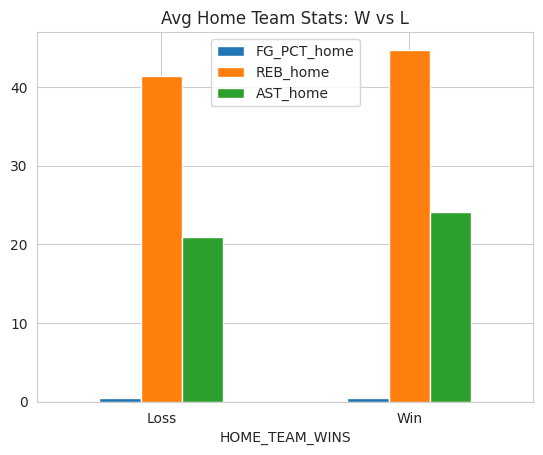

In [9]:
# To see if our features truly separate winners from losers, we show a grouped bar chart comparing our three features.
# The idea behind this plot is the variety of bars. Since they are of differnt ranges (low, medium, high), they justify our feature choices.
features = ['FG_PCT_home', 'REB_home', 'AST_home']
df.groupby('HOME_TEAM_WINS')[features].mean().plot(kind='bar')
plt.title("Avg Home Team Stats: W vs L")
plt.xticks([0,1], ['Loss', 'Win'], rotation=0)
plt.show()

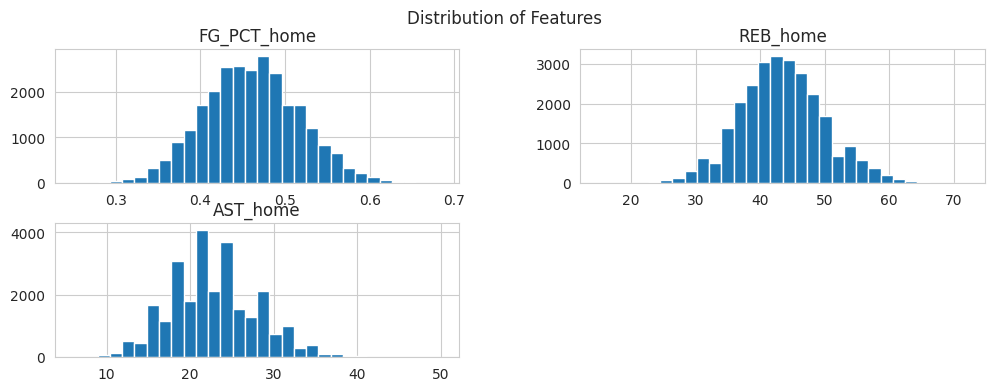

In [10]:
# For our second plot, a histogram will tell us whether or not our data is skewed or has outliers.
# As you can see, our data is not skewed
df[['FG_PCT_home', 'REB_home', 'AST_home']].hist(bins=30, figsize=(12,4))
plt.suptitle('Distribution of Features')
plt.show()

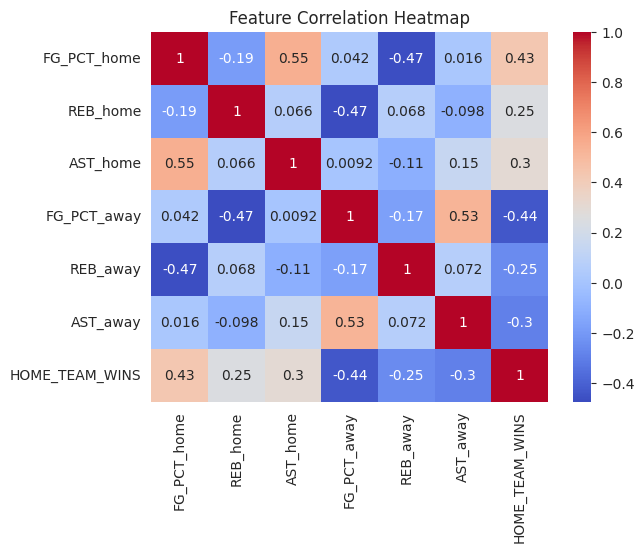

In [11]:
# Third plot
# Feature correlation heatmap determining if any mullticolinearity between features exists
# Now we can visually locate the strongest indicators of feature collaboration
cols = ['FG_PCT_home','REB_home','AST_home','FG_PCT_away','REB_away','AST_away','HOME_TEAM_WINS']
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

---

## Model 1

In [12]:
# Split the model up into training/testing sets at an 80/20 split
# Include stratification to make sure that the distribution between classes is consistent across both of the sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# This preprocessing pipeline makes sure that all numerical features are scaled, so that they are all relative to each other and can be compared. For Logisitic Regression models this is very important. 

preprocessor = ColumnTransformer(transformers=[
    ('num', MinMaxScaler(), num_feat)
])

# Now I complete the process and put the steps together in the correct order.

pipeline1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(solver='lbfgs', max_iter=1000))
])

pipeline1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse 

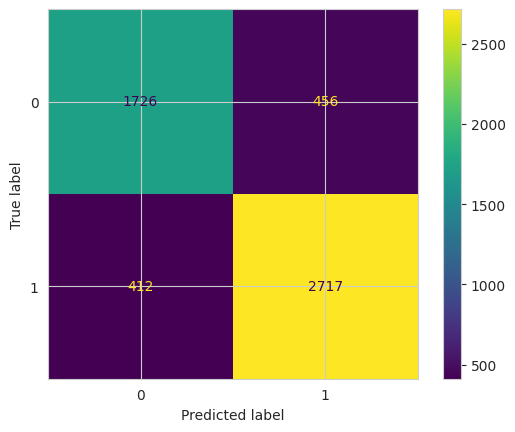

In [13]:
# Now that the model has been fit we can use it to make predictions based on the test set
y_pred = pipeline1.predict(X_test)
y_prob = pipeline1.predict_proba(X_test)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

The confusion matrix shows the model handles home-team wins really well, but struggles more with away wins. This is likely just a reflection of the 59% home-win base rate in the data. The higher volume of false negatives in relation to false positives suggests the model is seemingly biased toward the majority class. This is pretty expected for the baseline model as there is no class-weight adjustment yet, so we'll make changes to reflect these findings as we go.

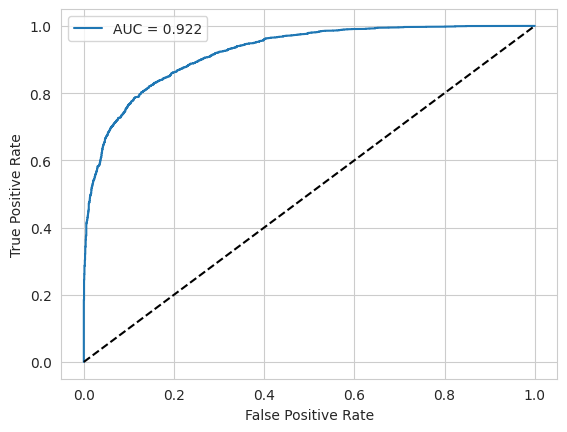

In [14]:
# ROC/AUC
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

The AUC shows us the difference between the True Positive Rate and the False Positive Rate at different thresholds. The AUC score being 0.922 shows us that the model is already very strong. The higher the AUC, the better the model is at classifying the different classes, so 0.922 is excellent.

In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80      2182
           1       0.86      0.87      0.86      3129

    accuracy                           0.84      5311
   macro avg       0.83      0.83      0.83      5311
weighted avg       0.84      0.84      0.84      5311



The model performs better on class 1 than 0, with overall accuracy of 0.84. This is very good, but as we go forward with the other models we will hopefully see improvement here. This model preducts the home wins with much higher recall thatn the away wins, similar to the 59% home win rate in the raw data. The AUC is well above .5, telling us that FG%, rebounds, and assists carry the game outcomes. I'm excited to see how the model continues to develop as we go and add complexity later on. 

---

## Model 2

Now let's test it with different solvers and see if that improves the model

Model 1 used the lbfgs solver which is better for smaller datasets, but doesn't work too well for larger datasets.
\
In Model 2, let's test the 'saga' and 'liblinear' solvers to see if this may improve the model as it attempts to classify the results of these NBA games. 


In [16]:
# Let's build the Model 2 pipeline just as we did previous, but with the saga solver this time. 
# Saga will likely be better for this dataset size, so I'm optimistic that we'll see improvmement

pipeline2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(solver='saga', max_iter=1000))
])

# We can fit the model on the same training and testing as we did in model 1
pipeline2.fit(X_train, y_train)

y_pred2 = pipeline2.predict(X_test)
y_prob2 = pipeline2.predict_proba(X_test)[:, 1]

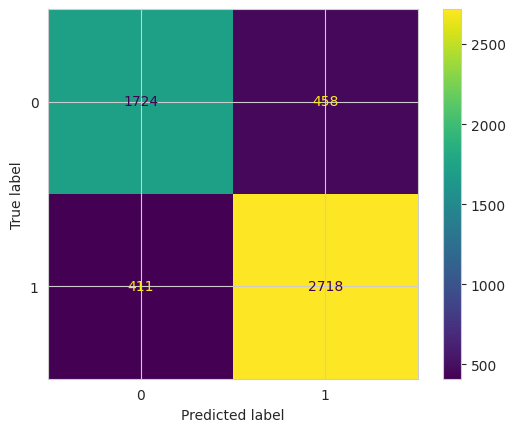

In [17]:
# Now we can build the Confusion Matrix again, for Model 2 this time
# The rows are the actual class, whereas the columns are the preductions that the model is making 
cm2 = confusion_matrix(y_test, y_pred2)
ConfusionMatrixDisplay(cm2).plot()
plt.show()

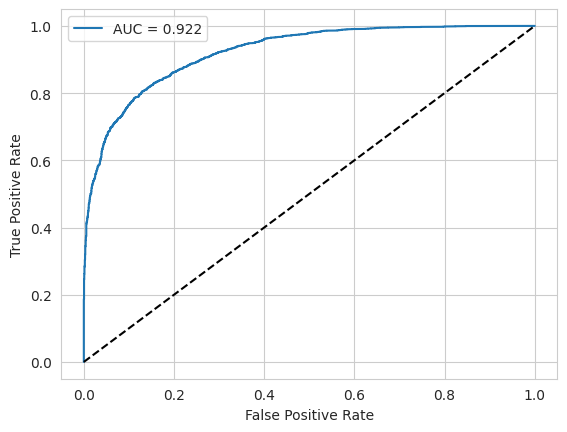

In [18]:
# Now we can go ahead and check the ROC for this model just like how we did previously
fpr2, tpr2, _ = roc_curve(y_test, y_prob2)
auc2 = roc_auc_score(y_test, y_prob2)

plt.plot(fpr2, tpr2, label=f'AUC = {auc2:.3f}')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [19]:
# Now we can check the classification report, and compare it to Model 1 to see any differences
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80      2182
           1       0.86      0.87      0.86      3129

    accuracy                           0.84      5311
   macro avg       0.83      0.83      0.83      5311
weighted avg       0.84      0.84      0.84      5311



Swapping the solver from lbfgs to saga produced virtually the same exact performance as model 1. The AUC score remained around 0.922, and the overall accuracy at roughly 94%. This confirms that the solver being used is not a meaningful aspect of this dataset, and just by simply changing the solver, we cannot improve the performance of the model. The model was still able to predict home team wins more reliably, and this was not changed with the different solver. When I substitute in the 'liblinear' solver here, nothing changes and we get pretty much the same exact results. This leads us to model 3, where we will try to address the class imbalance by making the weights balanced and cross-validation. Hopefully this will help the model succeed more, and we will see the AUC become even closer to 1.

---

## Model 3

In [20]:
# Create pipeline to be used in 3rd model
pipeline3 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=5000))
])
# We chose to use grid search with cross validation, so setting up hyperparamaters
param_grid = {
    'model__solver': ['liblinear', 'saga'],
    'model__class_weight': [None, 'balanced'],
    'model__C': [0.01, 0.1, 1, 10]
}

In [21]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
# Run Gridsearch
grid = GridSearchCV(
    pipeline3,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)
# fit the grid search model to our data
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=5000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__solver': ['liblinear', 'saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for

In [22]:
# Set model3 to highest scoring model from grid search
model3 = grid.best_estimator_

# predict for CM and grab probabilties for AUC curve 
y_pred3 = model3.predict(X_test)
y_prob3 = model3.predict_proba(X_test)[:, 1]

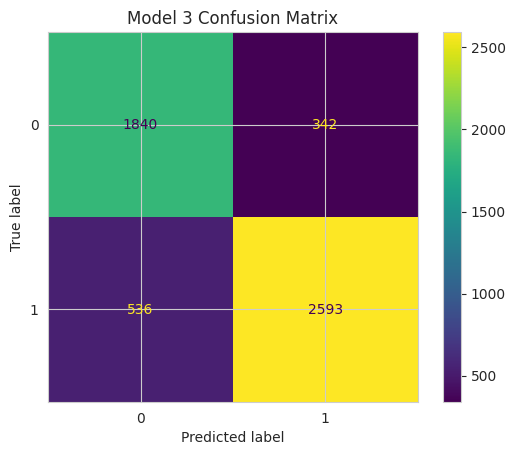

In [23]:
# Create cm for model 3
cm3 = confusion_matrix(y_test, y_pred3)
ConfusionMatrixDisplay(cm3).plot()
plt.title("Model 3 Confusion Matrix")
plt.show()

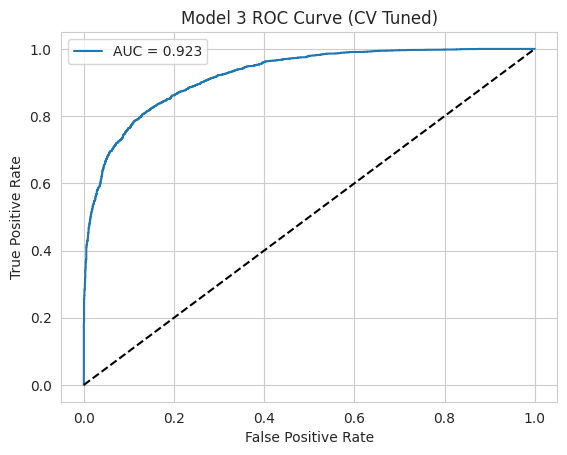

In [24]:
# Get false positive, and true positive rates
fpr3, tpr3, _ = roc_curve(y_test, y_prob3)
# Get auc score
auc3 = roc_auc_score(y_test, y_prob3)

#Plot AUC curve
plt.plot(fpr3, tpr3, label=f'AUC = {auc3:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Model 3 ROC Curve (CV Tuned)')
plt.legend()
plt.show()

Even with the grid search, the model didn't see any vast improvements. Currently, false positives and negatives have the same effect, as either is just our model predicting a win instead of a loss for either side. Overall, the model is very strong, but to improve it further, I'd hypothesize that we need to expiriment with transformations to features or change the features we are using.

---

## What features had the greatest importance to our project?

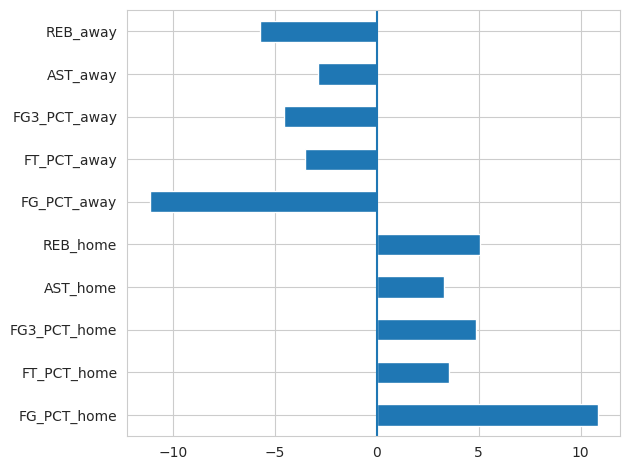

In [33]:
# So now that we've completed the 3 models, let's look into what features actually drove predictions
# The logistic regression coefficients will tell us how much each feature pushes the model toward predicting a home win (positive) or away win (negative)

# This pulls the coefficient from the best model (model 3), and pairs it with the feature names
coefs = pd.Series(model3.named_steps['model'].coef_[0], index=num_feat)

# Now we can plot the coefficients as a horizontal bar chart
coefs.plot(kind='barh')

# We'll add a vertical line at 0 so it's easy to see which features push toward a win vs a loss
plt.axvline(0)

plt.tight_layout()
plt.show()

Great! Now we can see from the chart that FG% for home teams has the largest positive coefficient, making shooting efficiency the strongest predictor of a home win. The FG% away mirrors this, confirming that when the away team shoots well, it really cancels out the home court advantage. Rebounding and assists for both teams have a meaningful affect, but much smaller. This shows that while playmaking and rebounding are big contributors, they are still secondary to shooting efficiency. This answers the main question that our project is answering, that yes, in-game stats can predict game outcomes very well, and field goal percentage is the strongest predictor

---

## Team Contribution

### Kyle

I was responsible for the cleaning and preprocessing work with the dataset we had, analyzing the summary statistics to decide which columns to drop to avoid data leakage and ensure the model integrity. I then built Models 1 and 2, implementing the logistic regression pipeline with different solvers and documenting the results of each with my summaries and commentary. Finally, I added the feature importance section after Model 3, extracting and visualizing the logistic regression coefficients to try to identify which in-game statistics had the greatest influence on our model's predictions.